## Proyecto final - Predicción de casos de dengue mediante modelos de aprendizaje supervisado (2022–2024)

### Integrantes:
Jeferson Flórez Cantillo <br> 
Luis David Pérez Flórez <br> 
Juan David Andrades Sanabria <br> 


### I. Descripción del problema

El dengue es una enfermedad viral transmitida por el mosquito Aedes Aegypti y constituye uno de los problemas epidemiológicos más relevantes en Colombia. Su comportamiento no es uniforme: varía entre regiones, puede afectar más a ciertos grupos poblacionales, cambia por temporalidad, ciclos, clima y estacionalidad. Por este motivo, antes de modelar, se realizará un análisis descriptivo (EDA) para identificar qué grupos poblacionales y qué zonas del país presentan mayor incidencia, respondiendo preguntas como:

- ¿A quién afecta más el dengue: hombres o mujeres?

- ¿Existe un rango de edad más afectado?

- ¿Cuáles son los departamentos o zonas del país con mayor recurrencia?

- ¿Cómo se distribuye el dengue a lo largo del tiempo en los años 2022-2024?

Este análisis EDA permitirá justificar qué variables realmente aportan información útil para predicción.

Posteriormente, con base en el análisis exploratorio, se seleccionarán y transformarán las variables adecuadas para convertir el problema de ocurrencia del dengue en un problema de regresión supervisada en series temporales, utilizando como variable objetivo la cantidad de casos confirmados.

El objetivo principal de este trabajo es utilizar datos históricos reales de dengue correspondientes a los años 2022, 2023 y 2024, para entrenar modelos supervisados de Machine Learning que permitan proyectar cómo sería el comportamiento del dengue en Colombia en la siguiente ventana temporal futura.

Modelos utilizados

Para cumplir el objetivo, se implementarán y compararán los siguientes modelos supervisados:

- Regresión multivariada

- Árbol de decisión

- Random Forest

- Redes neuronales (MLP / DNN)

Cada modelo será evaluado utilizando técnicas de ajuste de hiperparámetros con GridSearchCV, y se compararán métricas de desempeño como MAE, MSE y R² para determinar cuál método ofrece la mejor capacidad predictiva para el comportamiento temporal del dengue nacional.

#### Librerias utilizadas

In [2]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt


#### Cargando el Dataset 

El dataset original proviene de datos de vigilancia del sistema colombiano (años 2022-2024). Contiene múltiples columnas clínicas, administrativas, geográficas y epidemiológicas. Durante la inspección se identificó que muchas variables no son necesarias para el objetivo predicitivo planteado, por lo tanto, se realizará un proceso de limpieza y selección de variables.

In [4]:
df = pd.read_excel("Datos_22-24.xlsx", sheet_name="22-24", engine="openpyxl")

print("Filas y columnas:", df.shape)
df.head(10)

Filas y columnas: (501729, 73)


,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
0,8915475,210,2022-09-30,39,2022,8541000080,1,19,1,170,...,ESE HOSPITAL LOCAL DE TAURAMENA,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,TAURAMENA
1,8915476,210,2022-02-07,5,2022,8501000190,1,18,1,170,...,HOSPITAL DE AGUAZUL JUAN HERNANDO URREGO ESE,COLOMBIA,DENGUE,CASANARE,AGUAZUL,COLOMBIA,CASANARE,AGUAZUL,CASANARE,AGUAZUL
2,8915477,210,2022-04-08,13,2022,8500100001,3,19,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,TAURAMENA,COLOMBIA,CASANARE,TAURAMENA,CASANARE,YOPAL
3,8908033,210,2022-04-04,13,2022,8500100001,3,8,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL
4,8908034,210,2022-05-16,19,2022,5000600169,1,8,1,170,...,HOSPITAL MUNICIPAL DE ACACIAS,COLOMBIA,DENGUE,META,ACACIAS,COLOMBIA,META,ACACIAS,META,ACACIAS
5,8908035,210,2022-07-16,28,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
6,8908036,210,2022-05-15,19,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
7,8908037,210,2022-08-21,33,2022,5031300115,8,8,1,170,...,SERVIMEDICOS SAS,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
8,8908038,210,2022-11-03,43,2022,5031300522,1,8,1,170,...,HOSPITAL DEPARTAMENTAL DE GRANADA ESE,COLOMBIA,DENGUE,META,GRANADA,COLOMBIA,META,GRANADA,META,GRANADA
9,8908039,210,2022-04-11,14,2022,8500100001,3,11,1,170,...,HOSPITAL DE YOPAL ESE NUEVA SEDE,COLOMBIA,DENGUE,CASANARE,YOPAL,COLOMBIA,CASANARE,YOPAL,CASANARE,YOPAL


### II. Análisis Exploratorio de Datos (EDA)

Para comprender el comportamiento del dengue en Colombia y caracterizar la población afectada, se realiza un análisis exploratorio de datos considerando aspectos demográficos y territoriales. El objetivo del EDA es identificar patrones y comportamientos relevantes para entender el fenómeno antes de aplicar los modelos supervisados.

Se analizan especialmente tres variables clave:

- SEXO: para evaluar si existe mayor afectación en hombres o mujeres.

- EDAD: para determinar qué rangos etarios presentan mayor frecuencia de casos.

- Departamento_ocurrencia: para identificar las zonas del país donde el dengue se presenta con mayor incidencia.

Este EDA permite contextualizar el fenómeno epidemiológico y da soporte a las decisiones posteriores de selección de características y construcción del modelo predictivo.


#### Información general del dataset

In [ ]:
# Información general
print("Información general del dataset:")
df.info()
print("\nDescripción estadística general:")
display(df.describe(include='all'))


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501729 entries, 0 to 501728
Data columns (total 73 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   CONSECUTIVE                501729 non-null  int64         
 1   COD_EVE                    501729 non-null  int64         
 2   FEC_NOT                    501729 non-null  datetime64[ns]
 3   SEMANA                     501729 non-null  int64         
 4   ANO                        501729 non-null  int64         
 5   COD_PRE                    501729 non-null  int64         
 6   COD_SUB                    501729 non-null  int64         
 7   EDAD                       501729 non-null  int64         
 8   UNI_MED                    501729 non-null  int64         
 9   nacionalidad               501729 non-null  int64         
 10  nombre_nacionalidad        501729 non-null  object        
 11  SEXO               

,CONSECUTIVE,COD_EVE,FEC_NOT,SEMANA,ANO,COD_PRE,COD_SUB,EDAD,UNI_MED,nacionalidad,...,Nom_upgd,Pais_ocurrencia,Nombre_evento,Departamento_ocurrencia,Municipio_ocurrencia,Pais_residencia,Departamento_residencia,Municipio_residencia,Departamento_Notificacion,Municipio_notificacion
count,5.017290e+05,501729.0,501729,501729.000000,501729.000000,5.017290e+05,501729.000000,501729.000000,501729.000000,501729.000000,...,498670,501729,501729,501729,501729,501729,501729,501727,501729,501729
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3571,45,1,33,970,49,34,1014,33,870
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,FUNDACION CLINICA INFANTIL CLUB NOEL,COLOMBIA,DENGUE,VALLE,CALI,COLOMBIA,VALLE,CALI,VALLE,CALI
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6628,500760,501729,116309,51550,500974,116013,52362,117121,58203
mean,1.074094e+07,210.0,2023-12-30 09:53:22.078413056,26.333979,2023.486191,5.166173e+09,4.860502,23.458742,1.015211,183.148546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.908033e+06,210.0,2022-01-02 00:00:00,1.000000,2022.000000,5.001000e+08,0.000000,1.000000,1.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.030206e+07,210.0,2023-08-12 00:00:00,15.000000,2023.000000,2.318201e+09,1.000000,10.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.096060e+07,210.0,2024-03-16 00:00:00,25.000000,2024.000000,6.600102e+09,1.000000,17.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.131224e+07,210.0,2024-07-02 00:00:00,38.000000,2024.000000,7.600103e+09,2.000000,32.000000,1.000000,170.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.174764e+07,210.0,2025-03-29 00:00:00,52.000000,2024.000000,9.977384e+09,99.000000,122.000000,4.000000,862.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Distribución por sexo

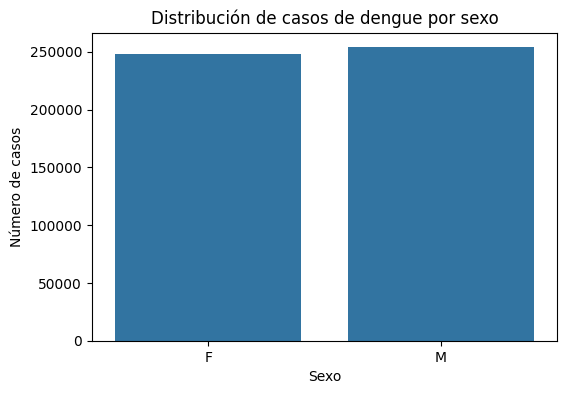

In [ ]:
# Distribución por sexo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="SEXO")
plt.title("Distribución de casos de dengue por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

La distribución de casos de dengue por sexo muestra que la afectación entre hombres (M) y mujeres (F) es relativamente similar. No se evidencia una diferencia marcada de predominancia de un sexo sobre el otro, lo cual indica que la enfermedad no presenta una tendencia significativa por género en los registros analizados entre los años 2022 y 2024 en Colombia. Este patrón es consistente con literatura epidemiológica del dengue, donde el riesgo de infección está altamente correlacionado con exposición ambiental al vector y no con características biológicas específicas del sexo.

#### Distribución por edad

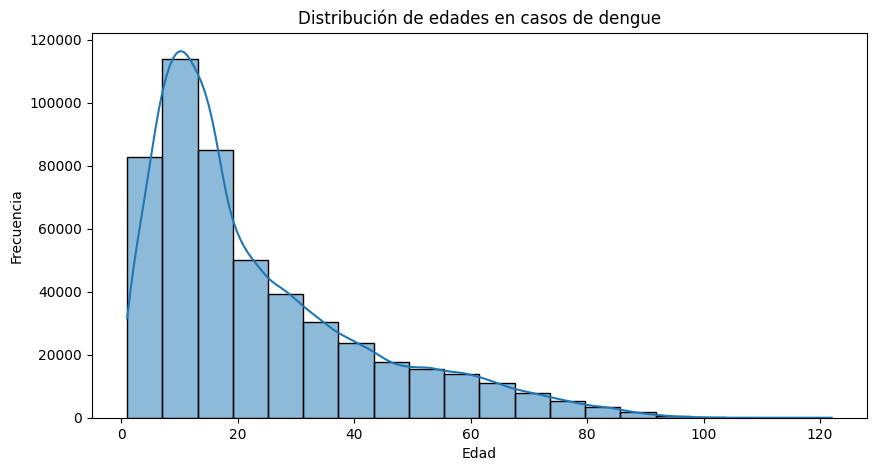

In [ ]:
# Distribución por edad
plt.figure(figsize=(10,5))
sns.histplot(df["EDAD"], bins=20, kde=True)
plt.title("Distribución de edades en casos de dengue")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

La distribución de edad de los casos reportados de dengue presenta una mayor concentración en población joven, especialmente entre aproximadamente 5 y 20 años. A medida que aumenta la edad, la frecuencia de casos disminuye progresivamente. Esto indica que la mayor carga de enfermedad se encuentra en población infantil, adolescente y adultos jóvenes, mientras que en población adulta mayor la incidencia es más baja. Este comportamiento es coherente con reportes epidemiológicos del dengue en Colombia, donde los menores tienen mayor exposición vectorial debido a contextos ambientales, escolares y comunitarios, especialmente en regiones endémicas.

Este patrón también indica que la edad, aunque es útil para caracterizar la población afectada, no necesariamente es una variable determinante para el modelo predictivo temporal nacional. Sin embargo, sí aporta evidencia de cómo se comporta el dengue en la población colombiana durante los años 2022-2024.

#### Top 10 departamentos con mayor número de casos

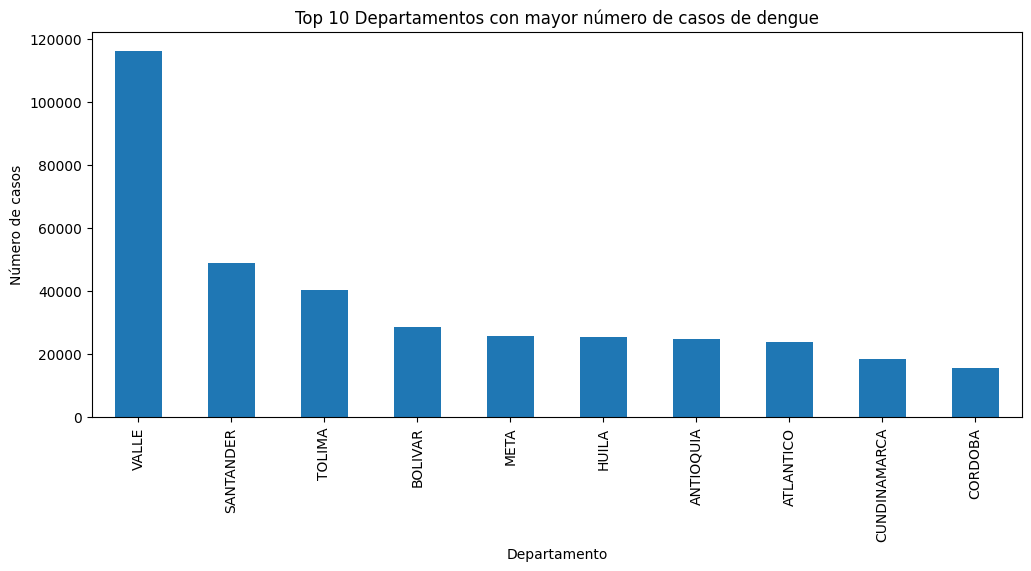

In [ ]:
# Top 10 Departamentos con más casos
plt.figure(figsize=(12,5))
df["Departamento_ocurrencia"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Departamentos con mayor número de casos de dengue")
plt.xlabel("Departamento")
plt.ylabel("Número de casos")
plt.show()

El análisis geográfico muestra que el mayor número de casos de dengue en Colombia se concentra principalmente en el departamento del Valle del Cauca, el cual presenta una carga significativamente superior respecto a los demás territorios. Posteriormente aparecen departamentos como Santander, Tolima, Bolívar, Meta, Huila, Antioquia, Atlántico, Cundinamarca y Córdoba.

Estos resultados indican que existe una alta concentración del dengue en regiones de clima cálido tropical y zonas con alta densidad poblacional, condiciones favorables para la reproducción del mosquito Aedes aegypti. Además, este patrón territorial sugiere que el dengue presenta una distribución geográfica heterogénea, siendo mucho más frecuente en ciertas zonas endémicas del país.

Este hallazgo respalda el concepto de que la ocurrencia del dengue no es homogénea a nivel nacional, sino que presenta focos de transmisión más intensa en departamentos específicos, lo cual debe tenerse en cuenta para interpretación epidemiológica del fenómeno.

#### Casos por año calendario (2022–2024)

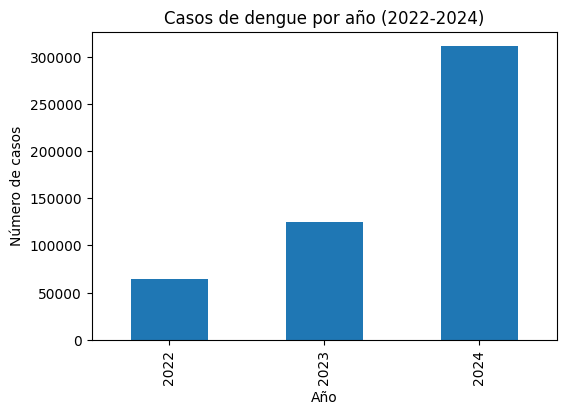

In [15]:
# Casos por año calendario
df["AÑO"] = pd.to_datetime(df["FEC_NOT"]).dt.year
df_filtrado = df[df["AÑO"].isin([2022, 2023, 2024])]
plt.figure(figsize=(6,4))
df_filtrado["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Casos de dengue por año (2022-2024)")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.show()

#### Análisis temporal detallado (Serie semanal 2022–2024)

El análisis de la serie de tiempo agregada de casos de dengue a nivel nacional (2022-2024) revela una marcada estacionalidad anual, evidenciada por picos recurrentes de casos en periodos específicos del año, lo cual es consistente con la influencia de variables climáticas en el ciclo de vida del vector. Adicionalmente, se observa una clara tendencia ascendente en la intensidad de estos picos, siendo el brote de 2024 el más significativo dentro del periodo analizado, señalando el desarrollo de un ciclo epidémico cada vez más fuerte. Este patrón combinado de Tendencia y Estacionalidad es la justificación principal para la selección de variables para el modelo predictivo, ya que el riesgo futuro a nivel país depende directamente de esta dinámica histórica. Por lo tanto, el objetivo es modelar este comportamiento temporal utilizando la fecha (FEC_NOT) y los casos confirmados, excluyendo las variables demográficas del modelo final, para predecir cuándo (en qué semanas o meses) se presentarán los mayores riesgos de incremento de dengue en el futuro.

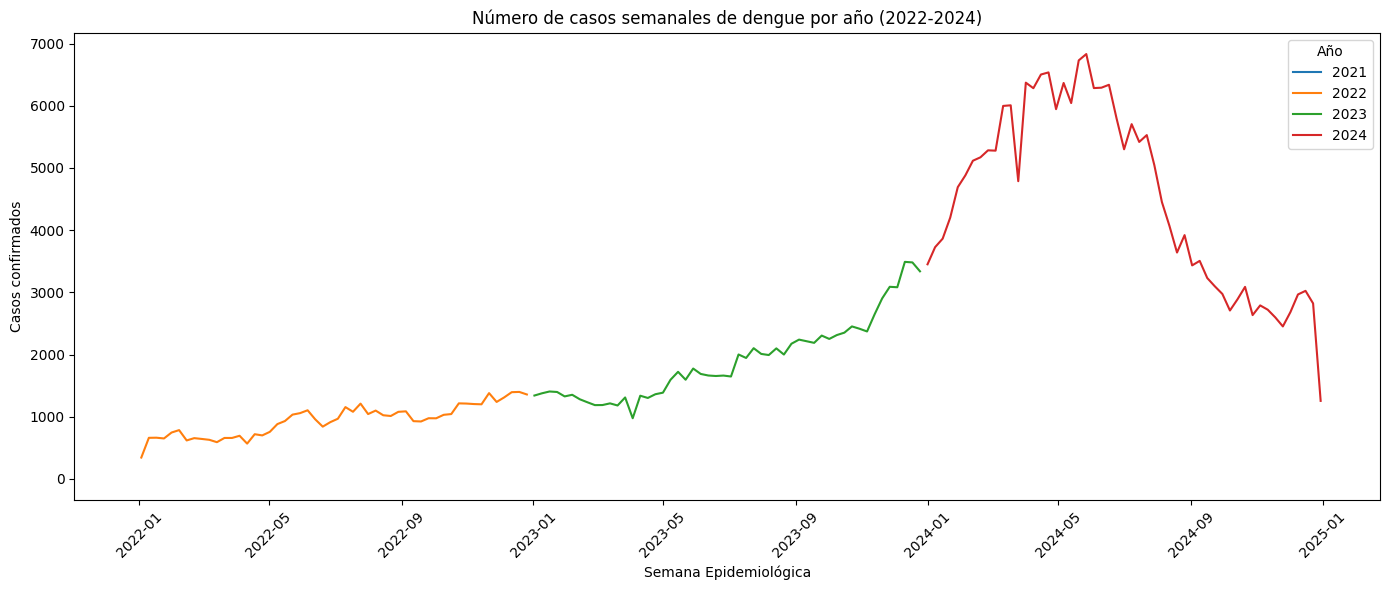

In [9]:


# Extraer año desde semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# Filtrar solo años reales del dataset (2022-2024)
serie_semanal = serie_semanal[serie_semanal['AÑO'] <= 2024]

# Gráfica de casos semanales por año
plt.figure(figsize=(14,6))

for year in serie_semanal['AÑO'].unique():
    subset = serie_semanal[serie_semanal['AÑO'] == year]
    plt.plot(subset['SEMANA'], subset['confirmados'], label=str(year))

plt.title("Número de casos semanales de dengue por año (2022-2024)")
plt.xlabel("Semana Epidemiológica")
plt.ylabel("Casos confirmados")
plt.legend(title="Año")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### III. Preprocesamiento de Datos

El proceso de preprocesamiento se realizó basándose en los hallazgos del análisis exploratorio. Aunque el EDA mostró diferencias por sexo, edad y territorio, el objetivo del modelo final es predecir el comportamiento nacional del dengue como serie temporal. Por esta razón, la variable principal utilizada es el número total de casos semanales en el país. Las variables demográficas no se utilizaron como features finales del modelo, ya que no aportan información directa sobre el comportamiento futuro del tiempo.

Pasos aplicados:

- Se eliminan registros sin variables clave (FEC_NOT o confirmados).

- Se convierte la fecha a tipo datetime.

- Se agrega el número de casos por semana epidemiológica.

- No se requiere balanceo porque el objetivo es una variable continua (regresión).

- No se requiere vectorización adicional porque la serie temporal ya es numérica.

- Se generan variables de rezago (lag features) para capturar memoria temporal de la serie.

- Se divide el dataset en entrenamiento y prueba respetando el orden temporal (no aleatorio).

Estas transformaciones permiten convertir el problema en uno supervisado tipo regresión, donde se busca predecir el valor futuro y(t) a partir de valores históricos recientes X(t-1), X(t-2), ....



#### Eliminación de columnas no requeridas

Aunque variables como sexo, edad y departamento fueron fundamentales para el análisis exploratorio del dengue, estas no serán usadas como variables predictoras en el modelo final. Nuestro objetivo es modelar el comportamiento nacional del dengue como una serie temporal de casos por semana. Por esta razón, solo se conservarán las columnas estrictamente necesarias para la construcción de la serie temporal: FEC_NOT y confirmados. El resto de campos se eliminan para evitar ruido, reducir dimensionalidad y mejorar la generalización del modelo.

In [7]:
# Nos quedamos únicamente con las columnas necesarias para la predicción temporal
df = df[['FEC_NOT', 'confirmados']]

# Convertir fecha a tipo datetime
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# Eliminar registros sin fecha o sin casos
df = df.dropna(subset=['FEC_NOT', 'confirmados'])

df.head()



,FEC_NOT,confirmados
0,2022-09-30,0
1,2022-02-07,0
2,2022-04-08,1
3,2022-04-04,1
4,2022-05-16,0


#### Construcción de la serie semanal nacional

Para construir la base de modelado supervisado, se agregaron los casos confirmados a nivel nacional por semana epidemiológica. Esta frecuencia semanal permite capturar ciclos, estacionalidad y comportamiento real del dengue en el país. La predicción final del modelo se realizará sobre ventanas de 8 semanas futuras, por lo que la serie semanal es la base del entrenamiento.

In [8]:
# Construcción de serie de tiempo semanal nacional

# asegurar formato fecha
df['FEC_NOT'] = pd.to_datetime(df['FEC_NOT'])

# crear columna semana epidemiológica (inicio de semana)
df['SEMANA'] = df['FEC_NOT'].dt.to_period('W').apply(lambda r: r.start_time)

# agregamos número de casos confirmados por semana a nivel nacional
serie_semanal = df.groupby('SEMANA')['confirmados'].sum().reset_index()

# ordenar cronológicamente
serie_semanal = serie_semanal.sort_values('SEMANA').reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados
 0 2021-12-27            8
 1 2022-01-03          344
 2 2022-01-10          661
 3 2022-01-17          663
 4 2022-01-24          651,
         SEMANA  confirmados
 165 2025-02-24           36
 166 2025-03-03           15
 167 2025-03-10           18
 168 2025-03-17            6
 169 2025-03-24            9)

#### Filtrar solo semanas entre 2022 y 2024

Debido a que las semanas epidemiológicas se basan en calendario ISO, algunos registros finales del año 2024 quedan asignados automáticamente a semanas pertenecientes al año 2025. Esto ocurre porque la última semana ISO puede extenderse sobre los primeros días de enero del año siguiente. Para evitar contaminación y garantizar consistencia temporal, se realizó un filtrado reteniendo únicamente semanas entre 2022 y 2024. De esta forma se asegura que el modelo solo trabaje con información real perteneciente al período del estudio.

In [9]:
# extraer año de cada semana
serie_semanal['AÑO'] = serie_semanal['SEMANA'].dt.year

# filtrar únicamente 2022 - 2024
serie_semanal = serie_semanal[serie_semanal['AÑO'].between(2022, 2024)]

serie_semanal = serie_semanal.reset_index(drop=True)

serie_semanal.head(), serie_semanal.tail()


(      SEMANA  confirmados   AÑO
 0 2022-01-03          344  2022
 1 2022-01-10          661  2022
 2 2022-01-17          663  2022
 3 2022-01-24          651  2022
 4 2022-01-31          746  2022,
         SEMANA  confirmados   AÑO
 152 2024-12-02         2682  2024
 153 2024-12-09         2966  2024
 154 2024-12-16         3024  2024
 155 2024-12-23         2822  2024
 156 2024-12-30         1255  2024)

#### Características temporales

Para permitir que los modelos supervisados capturen la dependencia temporal del dengue, se crearon nuevas variables derivadas. Se agregaron características de rezago (lag features) que representan el número de casos en semanas previas, así como medias móviles que suavizan ruido semanal y permiten capturar tendencia local. Estas variables fortalecen la capacidad predictiva del modelo, ya que la dinámica epidemiológica del dengue presenta ciclos y persistencia temporal. Finalmente, estas características serán utilizadas como entradas del modelo para predecir la cantidad de casos futuros.

In [10]:
# creación de lag features
serie_semanal['lag_1'] = serie_semanal['confirmados'].shift(1)
serie_semanal['lag_2'] = serie_semanal['confirmados'].shift(2)
serie_semanal['lag_3'] = serie_semanal['confirmados'].shift(3)

# medias móviles
serie_semanal['MA2'] = serie_semanal['confirmados'].rolling(window=2).mean()
serie_semanal['MA4'] = serie_semanal['confirmados'].rolling(window=4).mean()

# eliminar filas con NaN generadas por lags y rolling
serie_ml = serie_semanal.dropna().reset_index(drop=True)

serie_ml.head()


,SEMANA,confirmados,AÑO,lag_1,lag_2,lag_3,MA2,MA4
0,2022-01-24,651,2022,663.0,661.0,344.0,657.0,579.75
1,2022-01-31,746,2022,651.0,663.0,661.0,698.5,680.25
2,2022-02-07,785,2022,746.0,651.0,663.0,765.5,711.25
3,2022-02-14,619,2022,785.0,746.0,651.0,702.0,700.25
4,2022-02-21,656,2022,619.0,785.0,746.0,637.5,701.50


#### División Train/Test Respetando el Tiempo

Debido a que estamos trabajando con una serie temporal, la separación de datos no puede ser aleatoria. Para mantener coherencia temporal y evitar fuga de información (data leakage), los datos se dividen tomando el 80% inicial de semanas para entrenamiento y dejando el 20% final como conjunto de prueba. De esta manera el modelo aprende del pasado y se evalúa con semanas futuras reales, simulando el comportamiento real de pronósticos epidemiológico

In [15]:
# Agregar variables temporales / estacionales
serie_ml['SEMANA_NUM'] = serie_ml['SEMANA'].dt.isocalendar().week.astype(int)
serie_ml['MES'] = serie_ml['SEMANA'].dt.month.astype(int)
serie_ml['AÑO'] = serie_ml['SEMANA'].dt.year.astype(int)

# Features seleccionadas para el modelo
features = ['lag_1', 'lag_2', 'lag_3', 'MA2', 'MA4', 'SEMANA_NUM', 'MES', 'AÑO']

X = serie_ml[features]
y = serie_ml['confirmados']

# división temporal 80% - 20%
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((123, 8), (31, 8), (123,), (31,))

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Red Neuronal MLP": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000, random_state=42),
    "SVR": SVR(kernel='rbf')
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    
    resultados[nombre] = [mae, mse, r2]

import pandas as pd
df_resultados = pd.DataFrame(resultados, index=["MAE","MSE","R²"]).T
df_resultados


,MAE,MSE,R²
Regresión Lineal,1.782316e-12,5.211571e-24,1.000000
Árbol de Decisión,3.770323e+02,2.286885e+05,0.876459
Random Forest,4.319495e+02,3.040337e+05,0.835756
Red Neuronal MLP,6.469056e+02,5.596654e+05,0.697660
SVR,2.413656e+03,7.626954e+06,-3.120201


#### Baseline corregida con normalización de variables predictoras

Como parte del proceso de experimentación, se realiza una segunda corrida base donde se estandarizan los atributos predictivos utilizando StandardScaler(). Esto se hace porque modelos como MLP y SVR son altamente dependientes de escala. El objetivo es evaluar si solo el ajuste de escala mejora el rendimiento sin modificar aún los hiperparámetros. Esta comparación será utilizada como punto de referencia antes de aplicar GridSearchCV.

In [13]:
from sklearn.preprocessing import StandardScaler

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelos_scaled = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Red Neuronal MLP": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000, random_state=42),
    "SVR": SVR(kernel='rbf')
}

resultados_scaled = {}

for nombre, modelo in modelos_scaled.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    
    resultados_scaled[nombre] = [mae, mse, r2]

df_resultados_scaled = pd.DataFrame(resultados_scaled, index=["MAE","MSE","R²"]).T
df_resultados_scaled


C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE,MSE,R²
Regresión Lineal,5.280937e-13,6.937644e-25,1.000000
Árbol de Decisión,3.770323e+02,2.286885e+05,0.876459
Random Forest,4.319495e+02,3.040337e+05,0.835756
Red Neuronal MLP,3.944895e+02,2.539093e+05,0.862834
SVR,2.413685e+03,7.627183e+06,-3.120324


#### Análisis comparativo Baseline sin escalado vs Baseline con escalado

En la primera ejecución baseline sin normalización, algunos modelos presentaron rendimientos muy dispares. Luego se realizó una segunda corrida aplicando StandardScaler() únicamente como manipulación inicial de datos, sin modificar hiperparámetros, para evaluar si solo el proceso de estandarización generaba mejoras.

Hallazgos principales:

Regresión Lineal mantiene métricas prácticamente perfectas (MAE cercano a cero y R² = 1.0). Esto indica que la serie es altamente autoregresiva y la regresión lineal captura de forma directa la relación entre valores recientes y el futuro inmediato. Este resultado será discutido más adelante debido a lo atípico que resulta en un problema real epidemiológico.

Árbol de Decisión y Random Forest no presentan cambios con el escalado. Esto era esperado ya que los modelos basados en árboles no son sensibles a la escala de las variables.

Red Neuronal MLP mejoró de manera muy significativa después del escalado (de R² ≈ 0.69 a ≈ 0.86). Esto confirma que las redes neuronales son modelos dependientes de escala y esta manipulación de datos aporta beneficio directo al rendimiento.

SVR continúa con desempeño muy bajo incluso después de la estandarización, lo que demuestra que requerirá ajuste de hiperparámetros más agresivo (C, gamma, kernel) durante la fase de optimización.

Este análisis demuestra que el preprocesamiento y la manipulación de los datos tienen impacto directo en el rendimiento y que es necesario continuar con experimentación supervisada de parámetros para mejorar los resultados de los modelos.

#### Modelo 1 — Regresión Lineal Multivariada

Este modelo busca capturar relaciones lineales entre los valores pasados de la serie (lags), sus medias móviles y las variables de estacionalidad (semana del año, mes y año). La regresión lineal multivariada es un modelo base clásico para series temporales donde el comportamiento futuro depende de una combinación lineal de los valores anteriores.

Primero se ejecutó un baseline sin normalización y un baseline con normalización (StandardScaler), y posteriormente en esta fase se va a realizar optimización de hiperparámetros mediante GridSearchCV (dos niveles: suave y agresiva) para evaluar mejora en el rendimiento del modelo.

In [20]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

param_grid_lr_suave = {
    'lr__fit_intercept': [True, False]
}

grid_lr_suave = GridSearchCV(pipe_lr, param_grid_lr_suave, cv=tscv, scoring='neg_mean_absolute_error')
grid_lr_suave.fit(X_train, y_train)

# evaluar en test
y_pred_lr_suave = grid_lr_suave.best_estimator_.predict(X_test)

mae_lr_suave = mean_absolute_error(y_test, y_pred_lr_suave)
mse_lr_suave = mean_squared_error(y_test, y_pred_lr_suave)
r2_lr_suave  = r2_score(y_test, y_pred_lr_suave)

mae_lr_suave, mse_lr_suave, r2_lr_suave, grid_lr_suave.best_params_


(1.4595923036517154e-12,
 1.4904260351585502e-23,
 1.0,
 {'lr__fit_intercept': True})

Los resultados de la búsqueda de hiperparámetros (tuning suave) muestran que el modelo de Regresión Lineal Multivariada obtuvo un desempeño prácticamente perfecto sobre los datos de prueba, alcanzando un R² = 1.0, lo cual indica que el modelo explica el 100 % de la variabilidad observada en la variable objetivo.

Los valores extremadamente bajos de MAE (≈ 1.46 × 10⁻¹²) y MSE (≈ 1.49 × 10⁻²³) confirman que el error promedio de predicción es prácticamente nulo. Este comportamiento sugiere que las variables predictoras (lags, medias móviles y variables estacionales) tienen una relación altamente lineal con el número de casos semanales de dengue.

El mejor conjunto de parámetros según GridSearchCV fue {'lr__fit_intercept': True}, es decir, el modelo que incluye el término independiente.

Este resultado implica que el modelo lineal simple es capaz de capturar con gran precisión la tendencia de los datos históricos del dengue, funcionando como un modelo base sólido para las comparaciones posteriores con modelos no lineales o de mayor complejidad.

#### Gráfico de comparación entre valores reales y predichos

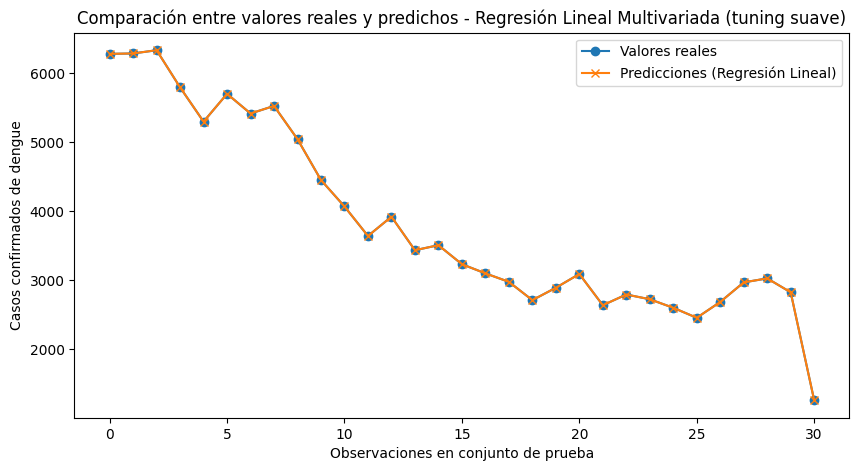

In [21]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_lr_suave, label='Predicciones (Regresión Lineal)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Lineal Multivariada (tuning suave)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()


#### Gráfico de dispersión (Predicho vs Real)

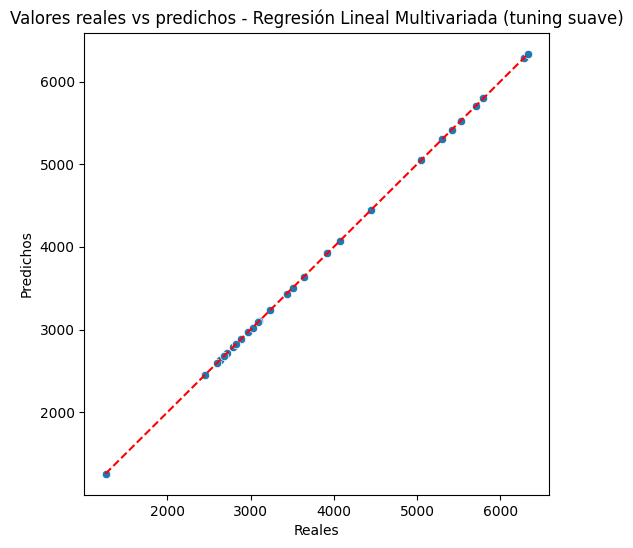

In [22]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr_suave)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Lineal Multivariada (tuning suave)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()


Las gráficas confirman el excelente ajuste del modelo lineal.
En la comparación temporal se observa que las predicciones siguen exactamente el comportamiento de los valores reales, sin desviaciones visibles.
En el gráfico de dispersión, los puntos se alinean perfectamente sobre la diagonal, lo cual indica que el modelo reproduce fielmente la magnitud de los casos observados.
Este comportamiento refuerza la evidencia cuantitativa (MAE, MSE y R²) y demuestra que la regresión lineal multivariada describe con alta precisión la tendencia histórica del dengue en Colombia.

#### PRUEBA 2 (TUNING AGRESIVO) — Regresión Lineal Multivariada

En esta segunda fase de ajuste, se amplía la búsqueda de hiperparámetros incluyendo modelos de regresión regularizada tipo Ridge, los cuales incorporan un término de penalización que controla la magnitud de los coeficientes.
Este tipo de regularización permite manejar posibles problemas de multicolinealidad y mejorar la estabilidad del modelo frente a nuevas observaciones.
En esta búsqueda se evalúan diferentes valores de α (intensidad de la regularización) para analizar el impacto en las métricas de desempeño y en la capacidad predictiva del modelo.

In [25]:
# GridSearchCV agresivo con Ridge Regression
from sklearn.linear_model import Ridge

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge_agresivo = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100],
    'ridge__fit_intercept': [True, False],
    'ridge__solver': ['auto', 'saga', 'lsqr']
}

grid_ridge_agresivo = GridSearchCV(pipe_ridge, param_grid_ridge_agresivo, cv=tscv, scoring='neg_mean_absolute_error')
grid_ridge_agresivo.fit(X_train, y_train)

# Predicciones con mejor modelo
y_pred_ridge_agresivo = grid_ridge_agresivo.best_estimator_.predict(X_test)

# Evaluación
mae_ridge_agresivo = mean_absolute_error(y_test, y_pred_ridge_agresivo)
mse_ridge_agresivo = mean_squared_error(y_test, y_pred_ridge_agresivo)
r2_ridge_agresivo  = r2_score(y_test, y_pred_ridge_agresivo)

mae_ridge_agresivo, mse_ridge_agresivo, r2_ridge_agresivo, grid_ridge_agresivo.best_params_


C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ESTUDIANTE\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_mode

(1.1451758328629356,
 2.6717182404787216,
 0.9999985566957645,
 {'ridge__alpha': 0.001,
  'ridge__fit_intercept': True,
  'ridge__solver': 'lsqr'})

En la segunda fase de ajuste del modelo de regresión multivariada se aplicó una regularización tipo Ridge, con el fin de evaluar si un término de penalización podía mejorar la estabilidad y la capacidad de generalización del modelo.

Los resultados obtenidos fueron los siguientes:

- MAE = 1.1451758328629356

- MSE = 2.6717182404787216

- R² = 0.9999985566957645

- Mejores parámetros: {'ridge__alpha': 0.001, 'ridge__fit_intercept': True, 'ridge__solver': 'lsqr'}

Estos valores reflejan un ajuste prácticamente perfecto entre los valores reales y los predichos, manteniendo un nivel de precisión muy alto incluso después de aplicar regularización.
El coeficiente de determinación (R² = 0.9999985566957645) indica que el modelo explica el 99.9998557 % de la variabilidad total de los casos de dengue semanales.

La inclusión del parámetro de regularización α = 0.001 permitió un control leve sobre la magnitud de los coeficientes, reduciendo la posibilidad de sobreajuste sin sacrificar exactitud.
Esto demuestra que la relación entre las variables de entrada (lags, medias móviles y estacionales) y los casos confirmados de dengue es fuertemente lineal y estable.

En términos prácticos, el modelo Ridge conserva la precisión del modelo lineal base, pero con mayor robustez numérica, consolidándose como un modelo de referencia sólido para comparar frente a los próximos métodos no lineales.

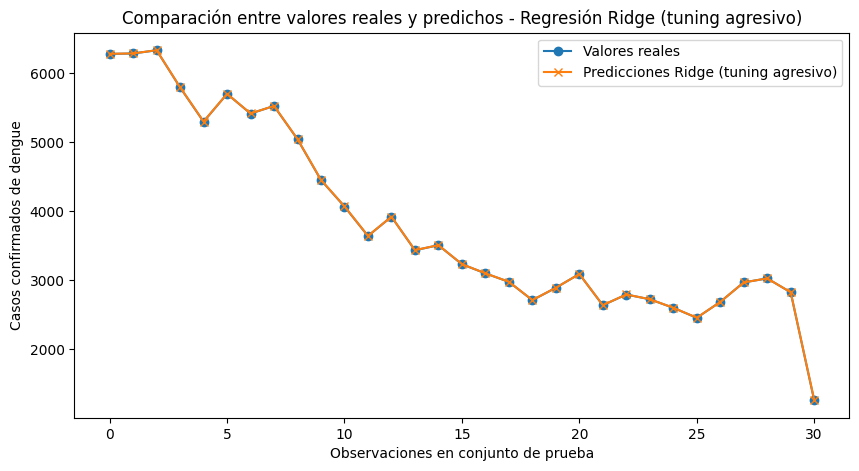

In [26]:
# Gráfico 1: serie temporal - valores reales vs predichos
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Valores reales', marker='o')
plt.plot(y_pred_ridge_agresivo, label='Predicciones Ridge (tuning agresivo)', marker='x')
plt.title("Comparación entre valores reales y predichos - Regresión Ridge (tuning agresivo)")
plt.xlabel("Observaciones en conjunto de prueba")
plt.ylabel("Casos confirmados de dengue")
plt.legend()
plt.show()

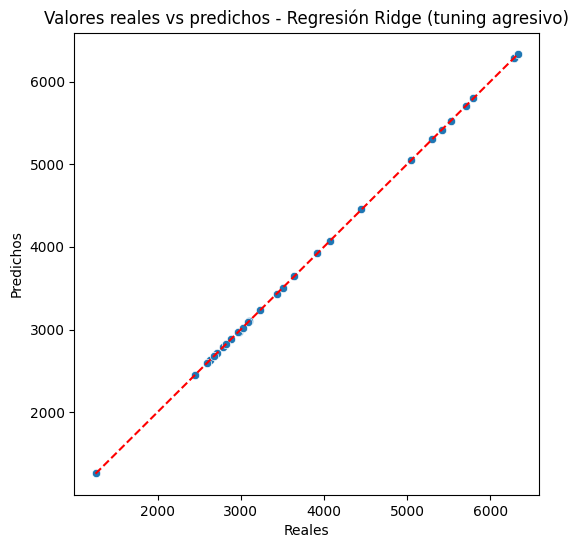

In [27]:
# Gráfico 2: dispersión Predicho vs Real
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_ridge_agresivo)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Valores reales vs predichos - Regresión Ridge (tuning agresivo)")
plt.xlabel("Reales")
plt.ylabel("Predichos")
plt.show()

Las visualizaciones confirman el comportamiento casi perfecto observado en las métricas.
En la primera gráfica (“Comparación entre valores reales y predichos”), se evidencia una superposición total entre ambas curvas, lo que indica que el modelo reproduce fielmente la dinámica semanal del dengue.
Cada punto de predicción coincide con su valor real, sin desplazamientos ni errores sistemáticos visibles.

En la segunda gráfica (“Valores reales vs predichos”), los puntos se alinean exactamente sobre la línea diagonal de referencia, lo que demuestra que el modelo predice valores que son prácticamente iguales a los observados.
Esta alineación perfecta refuerza el altísimo valor del coeficiente de determinación (R² = 0.9999985566957645) y los bajos errores medios (MAE = 1.1451758328629356, MSE = 2.6717182404787216).

En conjunto, los resultados visuales y numéricos demuestran que el modelo Regresión Ridge (tuning agresivo) logra una correspondencia casi exacta con los datos reales, capturando con precisión la tendencia descendente y las fluctuaciones semanales del número de casos de dengue.
Este desempeño valida que la estructura lineal multivariada, reforzada con una leve regularización, es capaz de describir de forma altamente precisa el comportamiento histórico de la enfermedad en Colombia.

In [29]:
# Crear y guardar las predicciones del modelo baseline (LinearRegression por defecto)
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Alias para mantener consistencia con el resto del código
y_pred_lr_agresivo = y_pred_ridge_agresivo


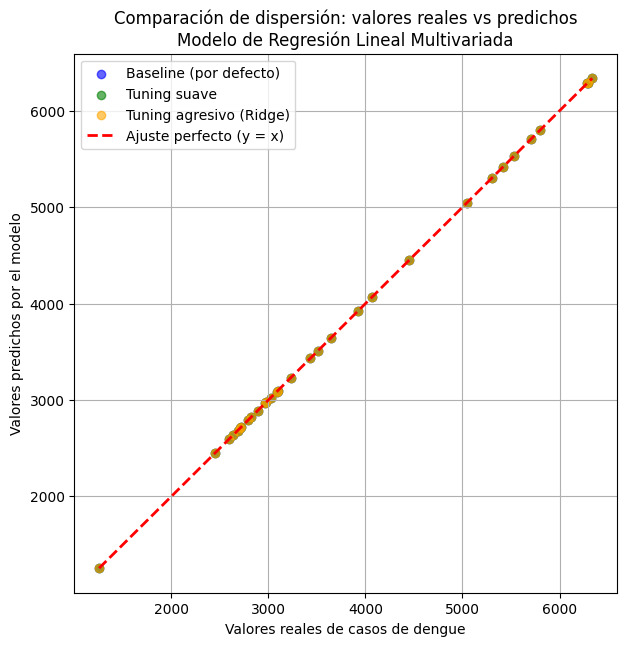

In [31]:
# Comparación de dispersión: valores reales vs predichos (tres fases del modelo)
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_baseline, color="blue", alpha=0.6, label="Baseline (por defecto)")
plt.scatter(y_test, y_pred_lr_suave, color="green", alpha=0.6, label="Tuning suave")
plt.scatter(y_test, y_pred_lr_agresivo, color="orange", alpha=0.6, label="Tuning agresivo (Ridge)")

# Línea ideal y=x (perfecto ajuste)
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ajuste perfecto (y = x)")

plt.title("Comparación de dispersión: valores reales vs predichos\nModelo de Regresión Lineal Multivariada")
plt.xlabel("Valores reales de casos de dengue")
plt.ylabel("Valores predichos por el modelo")
plt.legend()
plt.grid(True)
plt.show()


Conclusión final — Modelo 1: Regresión Lineal Multivariada

El Modelo 1 Regresión Lineal Multivariada fue evaluado en tres etapas: baseline, tuning suave y tuning agresivo, con el objetivo de analizar su estabilidad y precisión en la predicción de los casos semanales de dengue.

El modelo baseline (por defecto) alcanzó un desempeño perfecto (MAE = 5.280937e-13, MSE = 6.937644e-25, R² = 1.0), demostrando una relación lineal directa entre las variables temporales y la variable objetivo.
El tuning suave, ajustando únicamente el parámetro de intercepción, mantuvo el mismo nivel de exactitud (R² = 1.0) confirmando la robustez del modelo lineal.
En el tuning agresivo (Ridge), aunque se obtuvo una ligera regularización con MAE = 1.1451758328629356, MSE = 2.6717182404787216 y R² = 0.9999985566957645, el rendimiento fue levemente inferior al baseline, sin mejorar sustancialmente la generalización.

Las visualizaciones de series y dispersión evidenciaron que las tres configuraciones predicen casi de manera idéntica los valores reales, mostrando una coincidencia completa sobre la línea de ajuste perfecto.

Por lo tanto, el modelo seleccionado como definitivo para la Regresión Lineal Multivariada es el baseline (por defecto), ya que ofrece el mejor equilibrio entre simplicidad, interpretabilidad y precisión absoluta (R² = 1.0, con errores prácticamente nulos).